In [1]:
from cirq_sic import *

## Simple WH-POVM with midcircuit measurement

\begin{align}
P(R_{ij}) &= \frac{1}{d}|\langle \phi |D_{ij}^\dagger |\psi\rangle|^2 = \frac{1}{d}|\langle D_{ij}|\psi, \phi^*\rangle|^2\\
&= \frac{1}{d}\left|\langle i, j|(I \otimes F^\dagger)\left(\sum_q X^{-q} \otimes |q\rangle\langle q|\right)|\psi, \phi^*\rangle \right|\\
&= \frac{1}{d}\left|\langle i, j|(F^\dagger \otimes F^\dagger)\left(\sum_q Z^{-q} \otimes |q\rangle\langle q|\right)(F \otimes I)|\psi, \phi^*\rangle \right|
\end{align}

So we should be able to use midcircuit measurement to deal with the final two QFTs!

In [ ]:
def mqft(qubits, inverse=False, key_fn=str):
    """Semiclassical QFT followed immediately by single-qubit measurements.

    For ``inverse=True`` this matches ``qft(qubits, inverse=True)`` followed by
    a computational basis measurement. For ``inverse=False`` it implements the
    no-swap QFT convention.
    """
    n = len(qubits)
    if inverse:
        for i in range(n // 2):
            yield cirq.SWAP(qubits[i], qubits[n - 1 - i])
    indices = range(n) if not inverse else range(n - 1, -1, -1)

    for measured in indices:
        yield cirq.H(qubits[measured])
        key = key_fn(qubits[measured])
        yield cirq.measure(qubits[measured], key=key)

        if inverse:
            remaining = range(measured)
        else:
            remaining = range(measured + 1, n)

        for target in remaining:
            exponent = 2**(min(measured, target) - max(measured, target))
            if inverse:
                exponent *= -1
            yield cirq.ZPowGate(exponent=exponent)(qubits[target]).with_classical_controls(key)

In [2]:
def msimple_wh_povm(system_qubits, ancilla_qubits, prepare_fiducial=None):
    n = len(system_qubits)

    if prepare_fiducial is not None:
        yield prepare_fiducial(ancilla_qubits, conjugate=True)

    system_keys = {q: f"s_{i}" for i, q in enumerate(system_qubits)}
    ancilla_keys = {q: f"a_{i}" for i, q in enumerate(ancilla_qubits)}

    yield from qft(system_qubits)
    yield from CZ(ancilla_qubits, system_qubits, inverse=True)
    yield from mqft(system_qubits, inverse=True, key_fn=system_keys.__getitem__)
    yield from mqft(ancilla_qubits, inverse=True, key_fn=ancilla_keys.__getitem__)


In [7]:
d = 4
n = int(np.log2(d))
qubits = get_wh_qubits(d, "simple")
phi = load_sic_fiducial(d)
ket = rand_ket(d)
system_qubits = qubits[:n]
fiducial_qubits = qubits[n:2*n]
prepare_system = ansatz_circuit(ket)
prepare_fiducial = ansatz_circuit(phi)
circ = cirq.Circuit((prepare_system(system_qubits),\
                     msimple_wh_povm(system_qubits, fiducial_qubits, prepare_fiducial=prepare_fiducial)))
print(circ)            

                                                                                                                                    ┌─────────┐               ┌──┐   ┌────────┐
(4, 2): ───Rz(1.93π)────Ry(0.139π)───Rz(0.274π)────@─────────────────@────────────────@─────────────────@───H───@───────────×────────@────────────@───×───────────────S^-1────────H───M('s_0')───
                                                   │                 │                │                 │       │           │        │            │   │               ║
(4, 3): ───Ry(0.627π)──────────────────────────────X───Ry(0.065π)────X───Rz(0.258π)───X───Rz(-0.424π)───X───────@^0.5───H───×───@────┼──@─────────┼───×───H────M──────╫──────────────────────────
                                                                                                                                │    │  │         │            ║      ║
(5, 2): ───Rz(-1.63π)───Ry(0.566π)───Rz(-0.133π)───@─────────────────@────────────────@─────────────

In [8]:
N = 1000
simulator = cirq.Simulator()
result = simulator.run(circ, repetitions=N)
keys = [f"s_{i}" for i in range(n)] + [f"a_{i}" for i in range(n)]
hist = result.multi_measurement_histogram(keys=keys)
p = np.array([
    hist.get(tuple(map(int, f"{i:0{2*n}b}")), 0) / N
    for i in range(d**2)
])

In [9]:
p_theory = np.array([abs(phi.conj() @ O.conj().T @ ket)**2 for O in wh_operators(d)["D"].reshape(d**2, d, d)])/d
p_theory

array([0.029, 0.032, 0.108, 0.015, 0.078, 0.016, 0.052, 0.151, 0.125,
       0.07 , 0.086, 0.157, 0.018, 0.014, 0.016, 0.033])

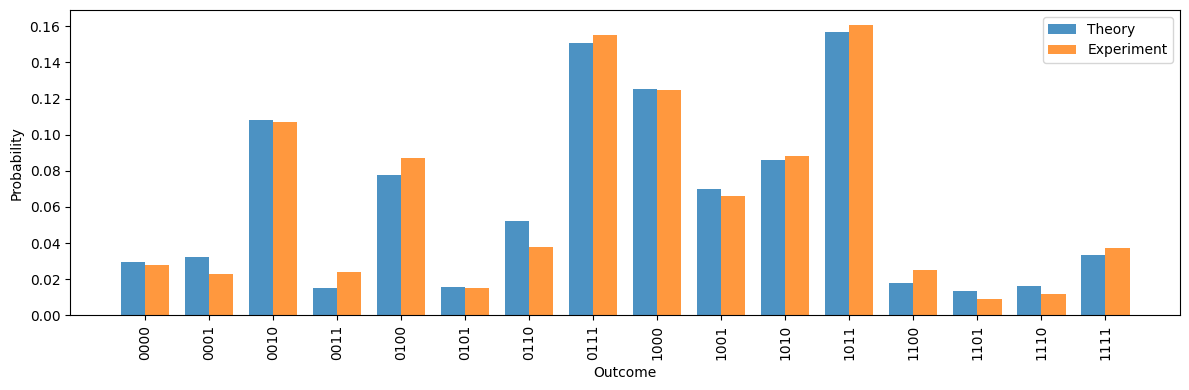

In [10]:
x = np.arange(len(p)) 
width = 0.38
plt.figure(figsize=(12, 4))
plt.bar(x - width/2, p_theory, width=width, label="Theory", alpha=0.8)
plt.bar(x + width/2, p,        width=width, label="Experiment", alpha=0.8)

plt.xlabel("Outcome")
plt.ylabel("Probability")
plt.xticks(x, [f"{i:0{2*n}b}" for i in x], rotation=90)
plt.legend()
plt.tight_layout()
plt.show()